<a href="https://colab.research.google.com/github/harsh0309/Machine-Learning-Projects/blob/main/email_spam_classification_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Load DataSet

In [1]:
import kagglehub
path = kagglehub.dataset_download("abdallahwagih/spam-emails")

100%|██████████| 207k/207k [00:00<00:00, 58.7MB/s]

Extracting files...


In [2]:
import os

print(path)
print(os.listdir(path))

/root/.cache/kagglehub/datasets/abdallahwagih/spam-emails/versions/1
['spam.csv']


In [3]:
import pandas as pd

df = pd.read_csv(os.path.join(path, "spam.csv"))  # adjust name if needed
print(df.head())
print(df.columns)

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
Index(['Category', 'Message'], dtype='object')


In [4]:
df.columns = [ 'label','text']   # change if order is different

In [5]:
print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [6]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['label']=le.fit_transform(df['label'])
df.head()


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.duplicated().sum()

np.int64(415)

In [9]:
df.drop_duplicates(keep='first',inplace=True)

In [10]:
df.shape

(5157, 2)

In [11]:
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# **2.EDA**

In [12]:
df['label'].value_counts()

,count
label,
0,4516
1,641


In [13]:
df['label'].value_counts()

,count
label,
0,4516
1,641


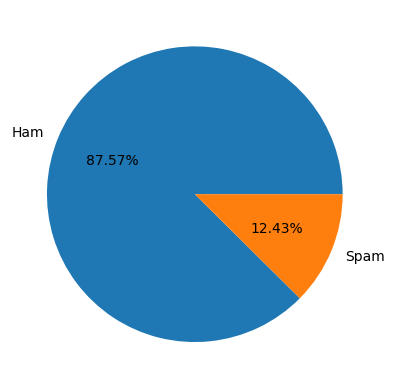

In [14]:
import matplotlib.pyplot as plt
plt.pie(df['label'].value_counts(), labels=['Ham', 'Spam'], autopct='%.2f%%')
plt.show()

In [15]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [16]:
df['No. of character']=df['text'].apply(len)
df.head()

,label,text,No. of character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [17]:
from nltk.tokenize import word_tokenize

df['num_words']=df['text'].apply(lambda x: len(word_tokenize(x)))
df.head()


,label,text,No. of character,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [18]:
df['No. of sentance']=df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.sample(5)

,label,text,No. of character,num_words,No. of sentance
1560,0,"Single line with a big meaning::::: ""Miss anyt...",123,34,1
4906,1,Warner Village 83118 C Colin Farrell in SWAT t...,181,41,4
3703,0,Hey loverboy! I love you !! I had to tell ... ...,158,40,7
4767,0,Whens your radio show?,22,5,1
1410,0,Where at were hungry too,24,5,1


In [19]:
df[['No. of character','num_words','No. of sentance']].describe()

,No. of character,num_words,No. of sentance
count,5157.000000,5157.000000,5157.000000
mean,79.103936,18.560403,1.969750
std,58.382922,13.405970,1.455526
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.000000
75%,118.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [20]:
#For Ham mail
df[df['label']==0][['No. of character','num_words','No. of sentance']].describe()

,No. of character,num_words,No. of sentance
count,4516.000000,4516.000000,4516.000000
mean,70.869353,17.267715,1.827724
std,56.708301,13.588065,1.394338
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,91.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [21]:
#For spam mail
df[df['label']==1][['No. of character','num_words','No. of sentance']].describe()

,No. of character,num_words,No. of sentance
count,641.000000,641.000000,641.000000
mean,137.118565,27.667707,2.970359
std,30.399707,7.103501,1.485575
min,7.000000,2.000000,1.000000
25%,130.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,223.000000,46.000000,9.000000


<Axes: xlabel='No. of character', ylabel='Count'>

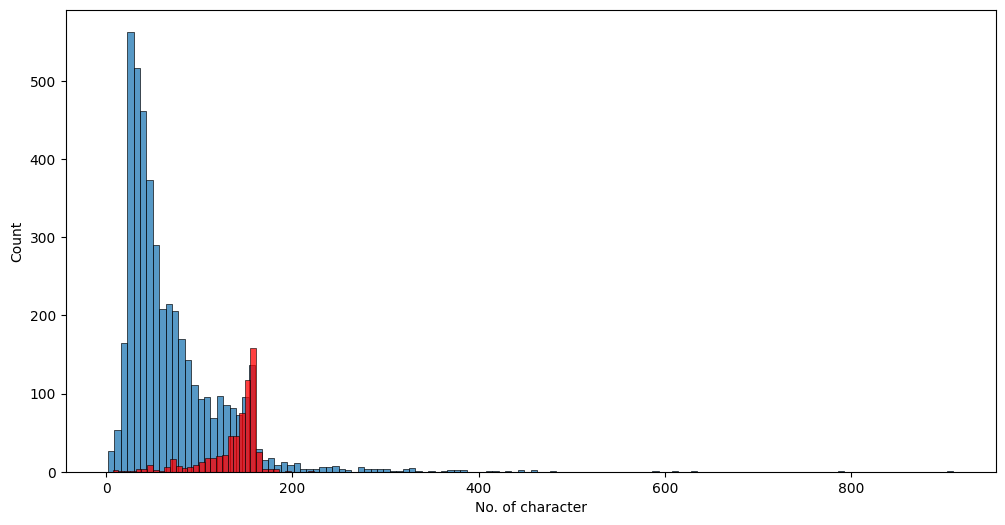

In [22]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.histplot(df[df['label']==0]['No. of character'])
sns.histplot(df[df['label']==1]['No. of character'],color='red')


<Axes: xlabel='num_words', ylabel='Count'>

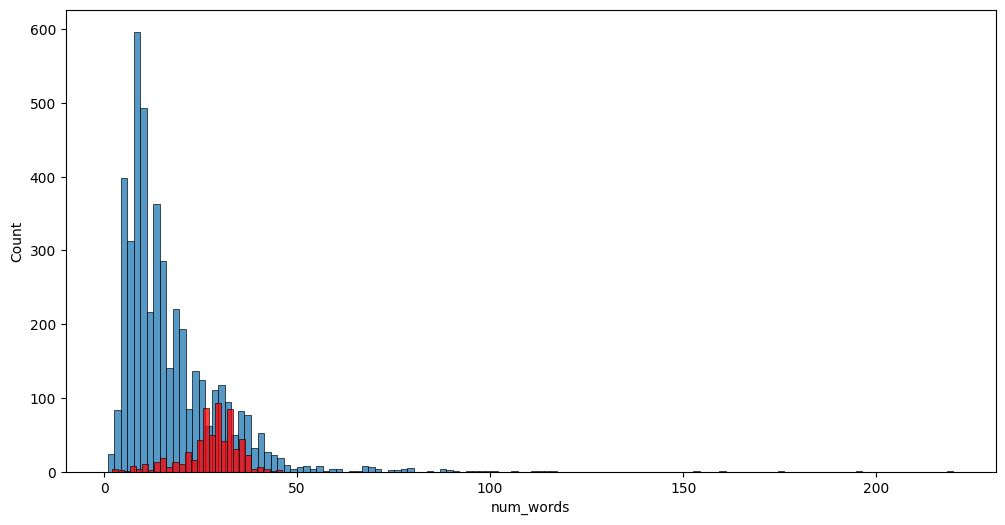

In [23]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['label']==0]['num_words'])
sns.histplot(df[df['label']==1]['num_words'],color='red')


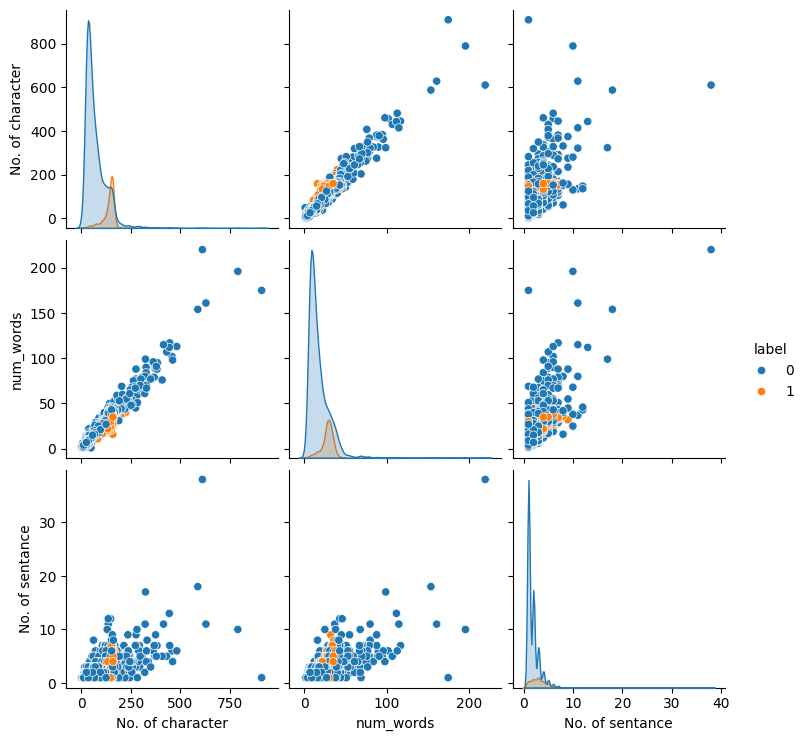

In [24]:
sns.pairplot(df,hue='label')

<Axes: >

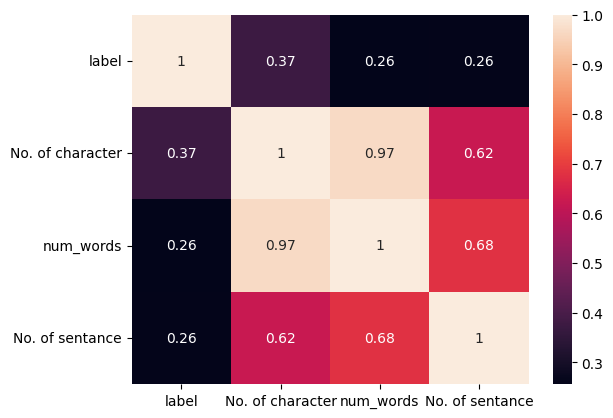

In [25]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# **3.Data Preprocessing**


*   LowerCase
*   Tokenization
*   Removing Special Character
*   Stemming







In [26]:
def Transform_text(text):
  text=text.lower()
  text=nltk.word_tokenize(text)
  y=[]
  for i in text:
    if (i.isalnum()):
      y.append(i)
  text=y[:]
  y.clear()
  for i in text:
    if (i not in stopwords.words('english') and i not in string.punctuation):
      y.append(i)
  text=y[:]
  y.clear()
  for i in text:
    y.append(ps.stem(i))

  return " ".join(y)


In [27]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords.words('english')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [28]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [29]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem('Dancing')

'danc'

In [30]:
df["transformed_text"]=df['text'].apply(Transform_text)

In [31]:
df.head()

,label,text,No. of character,num_words,No. of sentance,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [32]:
from wordcloud import WordCloud
wc=WordCloud(width=800,height=500,min_font_size=10,background_color='white')

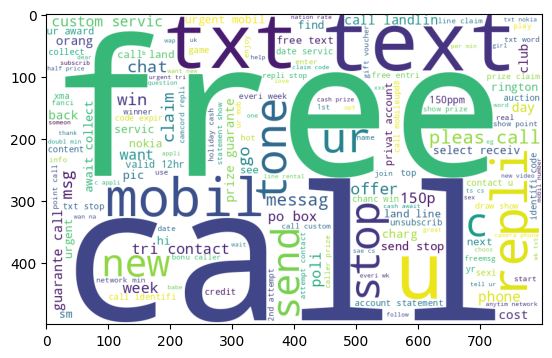

In [33]:
spam_wc=wc.generate(df[df['label']==1]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

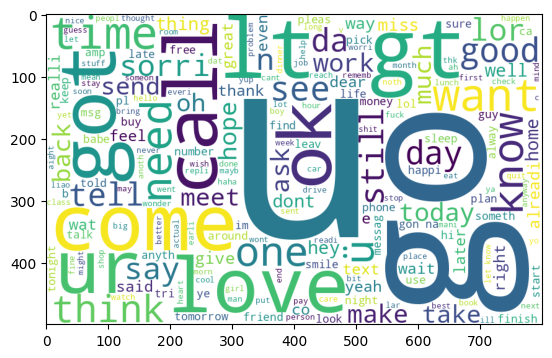

In [34]:
ham_wc=wc.generate(df[df['label']==0]['transformed_text'].str.cat(sep=" "))
plt.imshow(ham_wc)

In [35]:
spam_corpus=[]
for msg in df[df['label']==1]['transformed_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)
len(spam_corpus)

9781

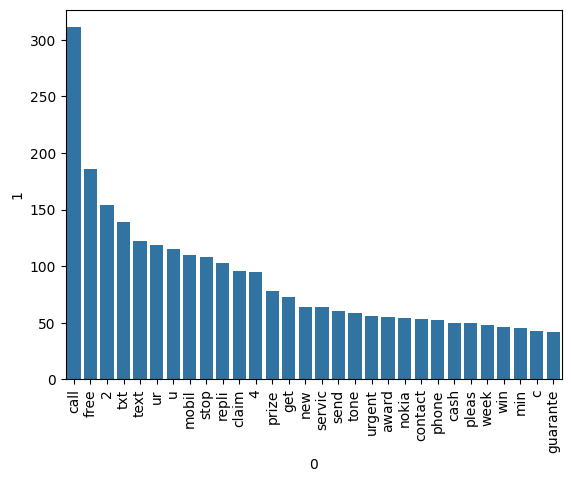

In [36]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],
            y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [37]:
ham_corpus=[]
for msg in df[df['label']==0]['transformed_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)
len(ham_corpus)

35940

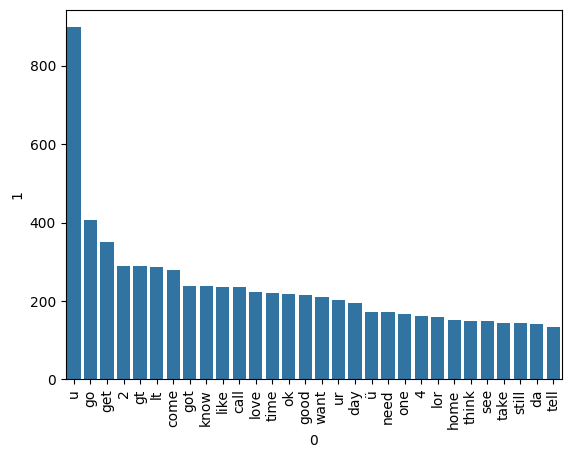

In [38]:
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],
            y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

# **3.Model Building**

In [39]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)



In [40]:
X=tfidf.fit_transform(df['transformed_text'])

X.shape


(5157, 3000)

In [41]:
y=df['label'].values

In [42]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [43]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 36875 stored elements and shape (5157, 3000)>

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=2)
#

In [45]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [46]:
gnb.fit(X_train.toarray(),y_train)
y_pred1=gnb.predict(X_test.toarray())
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8672480620155039
[[786 119]
 [ 18 109]]
0.4780701754385965


In [47]:
print(type(X_train))

<class 'scipy.sparse._csr.csr_matrix'>


In [48]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9718992248062015
[[905   0]
 [ 29  98]]
1.0


In [49]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9825581395348837
[[903   2]
 [ 16 111]]
0.9823008849557522


In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [51]:
svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
mnb=MultinomialNB()
dtc=DecisionTreeClassifier(max_depth=5)
lrc=LogisticRegression(solver='liblinear',penalty='l1')
rfc=RandomForestClassifier(n_estimators=50,random_state=2,max_samples=0.5,max_features=0.5)
abc=AdaBoostClassifier(n_estimators=50,random_state=2)
bc=BaggingClassifier(n_estimators=50,random_state=2)
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)
gbdt=GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb=XGBClassifier(n_estimators=50,random_state=2)

In [52]:
clfs={
    'SVC':svc,
    'KN':knc,
    'NB':mnb,
    'DT':dtc,
    'LR':lrc,
    'RF':rfc,
    'AdaBoost':abc,
    'BgC':bc,
    'ETC':etc,
    'GBDT':gbdt,
    'xgb':xgb

}

In [53]:
from sklearn.metrics import accuracy_score, precision_score,f1_score,recall_score
def train_classifier(clf,X_train,y_train,X_test,y_test):
  clf.fit(X_train,y_train)
  y_pred=clf.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  precision=precision_score(y_test,y_pred)
  recall=recall_score(y_test,y_pred)
  f1=f1_score(y_test,model.predict(X_test))

  return accuracy,precision,recall,f1

In [54]:
acc_list = []
prec_list = []
recall_list = []
f1_list = []


for name, model in clfs.items():
    current_accuracy, current_precision,current_recall,current_f1 = train_classifier(model, X_train, y_train, X_test, y_test)

    print("for", name)
    print("Accuracy -", current_accuracy)
    print("Precision -", current_precision)
    print("Recall -", current_recall)
    print("f1_score -",current_f1)

    acc_list.append(current_accuracy)
    prec_list.append(current_precision)
    recall_list.append(current_recall)
    f1_list.append(current_f1)

for SVC
Accuracy - 0.9777131782945736
Precision - 0.9905660377358491
Recall - 0.8267716535433071
f1_score - 0.9012875536480687
for KN
Accuracy - 0.9127906976744186
Precision - 1.0
Recall - 0.29133858267716534
f1_score - 0.45121951219512196
for NB
Accuracy - 0.9718992248062015
Precision - 1.0
Recall - 0.7716535433070866
f1_score - 0.8711111111111111
for DT
Accuracy - 0.936046511627907
Precision - 0.8144329896907216
Recall - 0.6220472440944882
f1_score - 0.7053571428571429
for LR
Accuracy - 0.9583333333333334
Precision - 0.9375
Recall - 0.7086614173228346
f1_score - 0.8071748878923767
for RF
Accuracy - 0.9563953488372093
Precision - 0.8796296296296297
Recall - 0.7480314960629921
f1_score - 0.8085106382978723
for AdaBoost
Accuracy - 0.9302325581395349
Precision - 0.8666666666666667
Recall - 0.5118110236220472
f1_score - 0.6435643564356436
for BgC
Accuracy - 0.9612403100775194
Precision - 0.8918918918918919
Recall - 0.7795275590551181
f1_score - 0.8319327731092437
for ETC
Accuracy - 0.9806

In [55]:
performance_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':acc_list,'Precision':prec_list,'Recall':recall_list,'f1_score':f1_list}).sort_values('Precision',ascending=False)

In [56]:
performance_df

,Algorithm,Accuracy,Precision,Recall,f1_score
1,KN,0.912791,1.000000,0.291339,0.451220
2,NB,0.971899,1.000000,0.771654,0.871111
8,ETC,0.980620,1.000000,0.842520,0.914530
0,SVC,0.977713,0.990566,0.826772,0.901288
9,GBDT,0.957364,0.977011,0.669291,0.794393
10,xgb,0.971899,0.953704,0.811024,0.876596
4,LR,0.958333,0.937500,0.708661,0.807175
7,BgC,0.961240,0.891892,0.779528,0.831933
5,RF,0.956395,0.879630,0.748031,0.808511
6,AdaBoost,0.930233,0.866667,0.511811,0.643564
